# Tech Challenge — Alfabetização

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

In [2]:

DATA_PATH = Path("/Users/gui/Documents/FIAP/FASE3/TechChallenge/Analise_Exploratoria/dataset_alfabetizacao_unificada.csv")


df_raw = pd.read_csv(DATA_PATH, sep=";", dtype=str, na_values=["", "NA", "N/A", "null", "None"])
df_raw.shape, df_raw.head()



((1048575, 64),
     ano  id_aluno id_escola id_municipio sigla_uf serie caderno rede_codigo  \
 0  2024  31032940  60020059      3170107       MG     2      10           3   
 1  2024  35398849  60026698      3550308       SP     2      10           2   
 2  2023  15017733  60001832      1501402       PA     2      10           2   
 3  2023  21008078  60004291      2111300       MA     2      10           3   
 4  2024  22030056  60006463      2205581       PI     2      10           3   
 
         rede presenca  ... meta_uf_2030 meta_brasil_taxa_alfabetizacao  \
 0  MUNICIPAL        0  ...         80.0                           59.2   
 1   ESTADUAL        0  ...         80.0                           59.2   
 2   ESTADUAL        0  ...         80.0                           55.9   
 3  MUNICIPAL        0  ...         80.0                           55.9   
 4  MUNICIPAL        0  ...         80.0                           59.2   
 
   meta_brasil_percentual_participacao meta_brasil

In [3]:
print('Colunas disponíveis:')
for col in df_raw.columns:
    print(col)

Colunas disponíveis:
ano
id_aluno
id_escola
id_municipio
sigla_uf
serie
caderno
rede_codigo
rede
presenca
preenchimento_caderno
alfabetizado
proficiencia
peso_aluno
municipio_taxa_alfabetizacao
municipio_media_portugues
municipio_prop_nivel_0
municipio_prop_nivel_1
municipio_prop_nivel_2
municipio_prop_nivel_3
municipio_prop_nivel_4
municipio_prop_nivel_5
municipio_prop_nivel_6
municipio_prop_nivel_7
municipio_prop_nivel_8
uf_taxa_alfabetizacao
uf_media_portugues
uf_prop_nivel_0
uf_prop_nivel_1
uf_prop_nivel_2
uf_prop_nivel_3
uf_prop_nivel_4
uf_prop_nivel_5
uf_prop_nivel_6
uf_prop_nivel_7
uf_prop_nivel_8
meta_municipio_taxa_alfabetizacao
meta_municipio_nivel_alfabetizacao
meta_municipio_percentual_participacao
meta_municipio_2024
meta_municipio_2025
meta_municipio_2026
meta_municipio_2027
meta_municipio_2028
meta_municipio_2029
meta_municipio_2030
meta_uf_taxa_alfabetizacao
meta_uf_percentual_participacao
meta_uf_2024
meta_uf_2025
meta_uf_2026
meta_uf_2027
meta_uf_2028
meta_uf_2029
met

### 1. Tratamento de tipos

A base contém números com separador de milhar, por exemplo `7.555.835`. Por isso, a conversão numérica remove pontos de milhar antes de converter. Colunas categóricas permanecem como texto.

In [4]:
def to_numeric_br(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    s = series.astype('string').str.strip()
    s = s.replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
    # Se houver mais de um ponto, trata os pontos como separadores de milhar.
    s = s.str.replace(r'(?<=\d)\.(?=\d{3}(?:\D|$))', '', regex=True)
    # Vírgula decimal, caso exista.
    s = s.str.replace(',', '.', regex=False)
    return pd.to_numeric(s, errors='coerce')

for col in df_raw.columns:
    if col not in ['sigla_uf', 'rede']:
        converted = to_numeric_br(df_raw[col])
        # Só substitui quando a conversão encontra valores numéricos suficientes.
        if converted.notna().mean() >= 0.50:
            df_raw[col] = converted

print(df_raw.dtypes)

ano                   Int64
id_aluno              Int64
id_escola             Int64
id_municipio          Int64
sigla_uf                str
                     ...   
meta_brasil_2026    Float64
meta_brasil_2027    Float64
meta_brasil_2028    Float64
meta_brasil_2029    Float64
meta_brasil_2030    Float64
Length: 64, dtype: object


### 2. Auditoria dos dados

In [5]:
id_cols = [c for c in ['ano', 'id_aluno'] if c in df_raw.columns]
if len(id_cols) == 2:
    duplicadas = df_raw.duplicated(id_cols, keep=False)
    print(f'Linhas duplicadas por ano + aluno: {duplicadas.sum():,}')
    print(f'Pares distintos ano + aluno: {df_raw[id_cols].drop_duplicates().shape[0]:,}')
else:
    print('Não foi possível auditar ano + id_aluno porque uma das colunas não existe.')

print('Distribuição por ano:')
display(df_raw['ano'].value_counts(dropna=False).sort_index())
print('Distribuição do alvo:')
display(df_raw['alfabetizado'].value_counts(dropna=False))

Linhas duplicadas por ano + aluno: 0
Pares distintos ano + aluno: 1,048,575
Distribuição por ano:


ano
2023    473136
2024    575439
Name: count, dtype: Int64

Distribuição do alvo:


alfabetizado
1    538755
0    509820
Name: count, dtype: Int64

### 3. Definição do target

O alvo é `alfabetizado`. IDs são mantidos para auditoria e ranking, mas não entram no modelo. Também são excluídas proficiência, indicadores de níveis, médias e taxas contemporâneas, pois são derivados do desempenho avaliado e podem revelar diretamente o resultado que queremos prever

In [ ]:
TARGET = 'alfabetizado'

# Colunas de identificação e auditoria — não são features.
ID_COLS = [c for c in ['ano', 'id_aluno', 'id_escola', 'id_municipio'] if c in df_raw.columns]

leakage_keywords = [
    'proficiencia', 'media_portugues', 'taxa_alfabetizacao',
    'prop_nivel_', 'nivel_alfabetizacao', 'percentual_participacao',
    'meta_', 'peso_aluno'
]

leakage_cols = [
    c for c in df_raw.columns
    if any(k in c.lower() for k in leakage_keywords)
]

# Nao tenho certeza se o caderno pode representar o instrumento da avaliação e não um contexto disponível antes da aplicação;
extra_excluded = [c for c in ['caderno', 'rede_codigo'] if c in df_raw.columns]

excluded = sorted(set([TARGET] + ID_COLS + leakage_cols + extra_excluded))
feature_cols = [c for c in df_raw.columns if c not in excluded]

print('Colunas excluídas:')
print(excluded)
print('Features utilizadas:')
print(feature_cols)

X_all = df_raw[feature_cols].copy()
y_all = pd.to_numeric(df_raw[TARGET], errors='coerce')
valid_target = y_all.isin([0, 1])
X_all = X_all.loc[valid_target].copy()
y_all = y_all.loc[valid_target].astype(int).copy()
meta = df_raw.loc[valid_target, [c for c in ID_COLS if c in df_raw.columns]].copy()

Colunas excluídas:
['alfabetizado', 'ano', 'caderno', 'id_aluno', 'id_escola', 'id_municipio', 'meta_brasil_2024', 'meta_brasil_2025', 'meta_brasil_2026', 'meta_brasil_2027', 'meta_brasil_2028', 'meta_brasil_2029', 'meta_brasil_2030', 'meta_brasil_percentual_participacao', 'meta_brasil_taxa_alfabetizacao', 'meta_municipio_2024', 'meta_municipio_2025', 'meta_municipio_2026', 'meta_municipio_2027', 'meta_municipio_2028', 'meta_municipio_2029', 'meta_municipio_2030', 'meta_municipio_nivel_alfabetizacao', 'meta_municipio_percentual_participacao', 'meta_municipio_taxa_alfabetizacao', 'meta_uf_2024', 'meta_uf_2025', 'meta_uf_2026', 'meta_uf_2027', 'meta_uf_2028', 'meta_uf_2029', 'meta_uf_2030', 'meta_uf_percentual_participacao', 'meta_uf_taxa_alfabetizacao', 'municipio_media_portugues', 'municipio_prop_nivel_0', 'municipio_prop_nivel_1', 'municipio_prop_nivel_2', 'municipio_prop_nivel_3', 'municipio_prop_nivel_4', 'municipio_prop_nivel_5', 'municipio_prop_nivel_6', 'municipio_prop_nivel_7', 

### 4. Separação temporal

O treino usa 2023 e o teste usa 2024. Isso representa melhor o uso futuro do modelo do que uma divisão aleatória que mistura anos.

In [7]:
if 'ano' not in df_raw.columns:
    raise ValueError('A coluna ano é necessária para a separação temporal.')

train_mask = df_raw.loc[valid_target, 'ano'].eq(2023).to_numpy()
test_mask = df_raw.loc[valid_target, 'ano'].eq(2024).to_numpy()

X_train, X_test = X_all.loc[train_mask].copy(), X_all.loc[test_mask].copy()
y_train, y_test = y_all.loc[train_mask].copy(), y_all.loc[test_mask].copy()
meta_test = meta.loc[test_mask].copy()

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError('A base precisa conter registros de 2023 e 2024 para esta avaliação.')

print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('Alvo treino:', y_train.value_counts(normalize=True).sort_index().to_dict())
print('Alvo teste:', y_test.value_counts(normalize=True).sort_index().to_dict())

Treino: (473136, 5) Teste: (575439, 5)
Alvo treino: {0: 0.4971340164350208, 1: 0.5028659835649792}
Alvo teste: {0: 0.47721478731889916, 1: 0.5227852126811009}


### 5. Pré-processamento e modelos

O input, padronização e codificação são aprendidas exclusivamente no treino por meio de `Pipeline` e `ColumnTransformer`. Desse jeito as  estatísticas do teste não vazam para o treinamento.

In [ ]:
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

# Encoding escolhido: OneHotEncoder, adequado para categorias nominais como UF, rede e série.
# O handle_unknown='ignore' ajuda a evitar erros caso apareça alguma uma categoria nova em 2024.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ],
    remainder='drop'
)

models = {
    'Regressão Logística': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=20,
            max_features='sqrt', class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} treinado.')

Regressão Logística treinado.
Random Forest treinado.


In [9]:
def evaluate_model(name, model):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'modelo': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba),
        'average_precision': average_precision_score(y_test, proba)
    }
    return metrics, pred, proba

results, predictions, probabilities = [], {}, {}
for name, model in models.items():
    metrics, pred, proba = evaluate_model(name, model)
    results.append(metrics)
    predictions[name] = pred
    probabilities[name] = proba

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
display(results_df)

,modelo,accuracy,precision,recall,f1,roc_auc,average_precision
0,Regressão Logística,0.665666,0.629930,0.873833,0.732101,0.711639,0.685987
1,Random Forest,0.666740,0.633796,0.858655,0.729287,0.712577,0.687909



Regressão Logística


,Predito 0,Predito 1
Real 0,120174,154434
Real 1,37955,262876


Erros totais: 192,389 de 575,439 (33.4%)
Falsos positivos: 154,434
Falsos negativos: 37,955


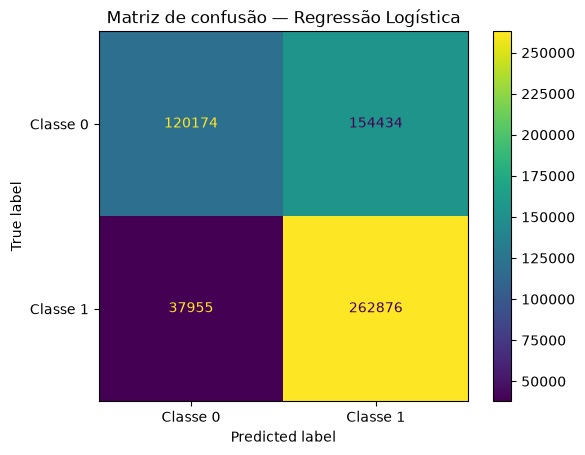


Random Forest


,Predito 0,Predito 1
Real 0,125358,149250
Real 1,42521,258310


Erros totais: 191,771 de 575,439 (33.3%)
Falsos positivos: 149,250
Falsos negativos: 42,521


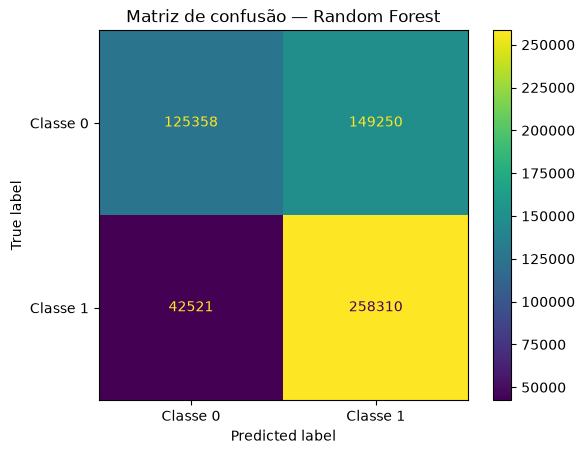

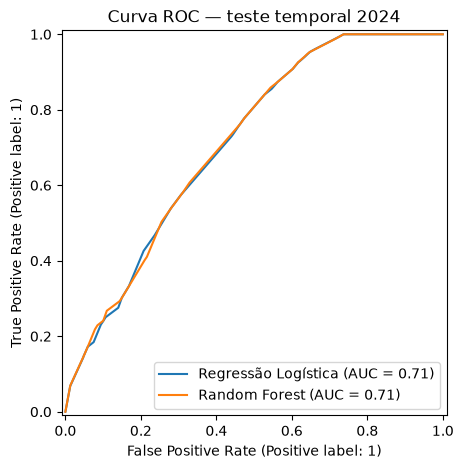

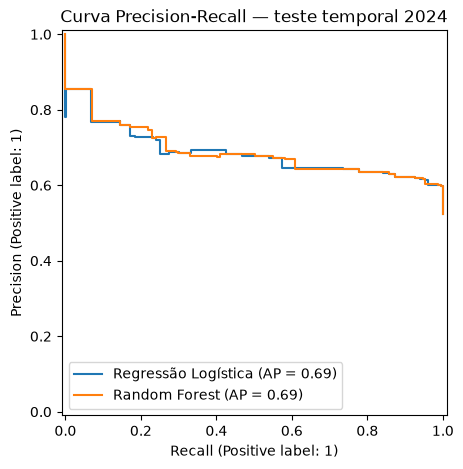

In [10]:
for name in models:
    print(f"\n{name}")
    cm = confusion_matrix(y_test, predictions[name], labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Predito 0', 'Predito 1'])
    display(cm_df)

    tn, fp, fn, tp = cm.ravel()
    erro_total = fp + fn
    print(f"Erros totais: {erro_total:,} de {len(y_test):,} ({erro_total / len(y_test):.1%})")
    print(f"Falsos positivos: {fp:,}")
    print(f"Falsos negativos: {fn:,}")

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1']).plot(values_format='d')
    plt.title(f'Matriz de confusão — {name}')
    plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name in models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.set_title('Curva ROC — teste temporal 2024')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name in models:
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
ax.set_title('Curva Precision-Recall — teste temporal 2024')
plt.show()

### 6. Interpretação l

O ranking municipal abaixo é um mecanismo de priorização: municípios com maior probabilidade média prevista de não alfabetização merecem investigação, não devem ser tratados automaticamente como casos confirmados.

In [11]:
best_name = results_df.iloc[0]['modelo']
best_model = models[best_name]

perm = permutation_importance(
    best_model, X_test, y_test, scoring='f1', n_repeats=5, random_state=42, n_jobs=-1
)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)
display(importance_df.head(20))

,feature,importance_mean,importance_std
4,preenchimento_caderno,0.042051,0.000317
3,presenca,0.041716,0.000321
0,sigla_uf,0.035434,0.000183
1,serie,0.000000,0.000000
2,rede,-0.000850,0.000091


In [12]:
if 'id_municipio' in meta_test.columns:
    risk_df = meta_test.copy()
    risk_df['prob_nao_alfabetizado'] = 1 - probabilities[best_name]
    risk_df['real_nao_alfabetizado'] = 1 - y_test.to_numpy()
    ranking_municipal = (
        risk_df.groupby('id_municipio', as_index=False)
        .agg(
            alunos=('prob_nao_alfabetizado', 'size'),
            risco_medio=('prob_nao_alfabetizado', 'mean'),
            taxa_real_nao_alfabetizado=('real_nao_alfabetizado', 'mean')
        )
        .query('alunos >= 30')
        .sort_values(['risco_medio', 'alunos'], ascending=[False, False])
    )
    display(ranking_municipal.head(20))
else:
    print('id_municipio não está disponível para o ranking municipal.')

,id_municipio,alunos,risco_medio,taxa_real_nao_alfabetizado
4331,4203204,416,0.999911,1.000000
4306,4202008,319,0.999911,1.000000
4546,4218004,211,0.910844,0.952607
2944,3162450,72,0.874965,0.930556
1980,2914505,46,0.831374,0.869565
80,1300300,202,0.803869,0.861386
91,1301100,122,0.775315,0.827869
1739,2800506,50,0.762203,0.580000
4311,4202107,206,0.754785,0.820388
1764,2803203,108,0.752332,0.638889


## 7. Resumo final e interpretação dos resultados

O modelo foi desenvolvido com separação temporal, utilizando 2023 para treinamento e 2024 para teste. O pré-processamento foi realizado dentro de um `Pipeline`, com imputação da mediana e `StandardScaler` para variáveis numéricas, além de imputação pela moda e `OneHotEncoder(handle_unknown="ignore")` para variáveis categóricas. Dessa forma, as transformações são aprendidas apenas com o conjunto de treino.

A matriz de confusão permite observar não apenas a acurácia, mas também os falsos positivos e falsos negativos. Para este problema, o recall é especialmente importante porque representa a capacidade de identificar os alunos pertencentes à classe de interesse. Um recall elevado indica que poucos alunos dessa classe ficaram sem ser identificados, embora isso possa aumentar o número de falsos positivos.

Os resultados devem ser interpretados como uma ferramenta de triagem e priorização, e não como uma decisão definitiva sobre o aluno. O modelo apresentou desempenho moderado em acurácia e capacidade discriminativa, mas mostrou potencial para localizar a classe de interesse com recall elevado.

As variáveis mais relevantes devem ser analisadas com cuidado. Caso `presenca` e `preenchimento_caderno` sejam informações disponíveis somente depois da aplicação, elas não devem ser usadas em uma previsão antecipada. Nesse caso, o modelo deve ser reexecutado sem essas colunas, deixando explícito que esse é o cenário mais adequado para uma intervenção preventiva.

Como limitação, a base possui poucas variáveis explicativas anteriores ao resultado da avaliação. A inclusão de histórico escolar, frequência anterior, características da escola, indicadores socioeconômicos e resultados de anos anteriores provavelmente teria maior potencial de melhoria do que apenas trocar o algoritmo. Portanto, o modelo atual é um baseline consistente, útil para demonstrar o processo de Machine Learning, mas ainda pode evoluir com novas features e validação adicional.

Prof Ortelan é 10

## 8. Avaliação adicional: modelo antecipativo

Avaliacao de uma versão sem `presenca` e `preenchimento_caderno`. Essas variáveis podem não estar disponíveis antes da aplicação da avaliação. Assim comparo o modelo original com uma versão talvez mais coerente com uma ação preventiva.

In [13]:
from sklearn.metrics import classification_report
features_pos_avaliacao = [c for c in ['presenca', 'preenchimento_caderno'] if c in X_train.columns]
X_treino_antecipado = X_train.drop(columns=features_pos_avaliacao, errors='ignore').copy()
X_teste_antecipado = X_test.drop(columns=features_pos_avaliacao, errors='ignore').copy()

colunas_numericas_ante = X_treino_antecipado.select_dtypes(include=['number', 'bool']).columns.tolist()
colunas_categoricas_ante = X_treino_antecipado.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessador_antecipado = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), colunas_numericas_ante),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), colunas_categoricas_ante)
])

modelo_antecipado = Pipeline([
    ('preprocessor', preprocessador_antecipado),
    ('classifier', RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=20,
        max_features='sqrt', class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])
modelo_antecipado.fit(X_treino_antecipado, y_train)
probabilidades_antecipadas = modelo_antecipado.predict_proba(X_teste_antecipado)[:, 1]
previsoes_antecipadas = (probabilidades_antecipadas >= 0.5).astype(int)

print('Features removidas:', features_pos_avaliacao)
print(classification_report(y_test, previsoes_antecipadas, zero_division=0))
print('ROC AUC:', roc_auc_score(y_test, probabilidades_antecipadas))


/var/folders/ls/bvtdvznd3q9bkwpbkcnpmykw0000gn/T/ipykernel_9228/1538093447.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas_ante = X_treino_antecipado.select_dtypes(include=['object', 'category']).columns.tolist()


Features removidas: ['presenca', 'preenchimento_caderno']
              precision    recall  f1-score   support

           0       0.53      0.63      0.58    274608
           1       0.60      0.50      0.54    300831

    accuracy                           0.56    575439
   macro avg       0.57      0.56      0.56    575439
weighted avg       0.57      0.56      0.56    575439

ROC AUC: 0.606865376850704


## 9. Matriz de confusão por classe

A matriz de confusão permite identificar não apenas o percentual total de acertos, mas também os tipos de erro. Para o nosso cenário, aproveitando as limitações da base origem inclusive, o falso negativo é especialmente importante quando a classe positiva representa o aluno em risco.

In [14]:
def confusion_summary(y_true, y_pred, model_name):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    total = cm.sum()

    print(f'\n{model_name}')

    print('Verdadeiros negativos:', tn)
    print('Falsos positivos:', fp)
    print('Falsos negativos:', fn)
    print('Verdadeiros positivos:', tp)
    print('Erros totais:', fp + fn)
    print(
        'Percentual de erros:',
        round((fp + fn) / total * 100, 2),
        '%'
    )

    return pd.DataFrame(
        cm,
        index=['Real 0', 'Real 1'],
        columns=['Previsto 0', 'Previsto 1']
    )


cm_rf_df = confusion_summary(
    y_test,
    predictions['Random Forest'],
    'Random Forest'
)

display(cm_rf_df)


Random Forest
Verdadeiros negativos: 125358
Falsos positivos: 149250
Falsos negativos: 42521
Verdadeiros positivos: 258310
Erros totais: 191771
Percentual de erros: 33.33 %


,Previsto 0,Previsto 1
Real 0,125358,149250
Real 1,42521,258310


In [15]:
probabilidades_rf = probabilities['Random Forest']

## 10. Avaliação de diferentes thresholds

O threshold padrão deixei com 0,50. Mas, como o objetivo é apoiar a identificação de alunos em risco, avalio outros limites. Um threshold menor tende a aumentar o recall da classe positiva, mas também pode aumentar os falsos positivos

In [16]:
probabilidades_rf = probabilities['Random Forest']

resultados_threshold = []
for threshold in np.arange(0.30, 0.71, 0.05):
    previsao_threshold = (probabilidades_rf >= threshold).astype(int)
    resultados_threshold.append({
        'threshold': round(float(threshold), 2),
        'accuracy': accuracy_score(y_test, previsao_threshold),
        'precision': precision_score(y_test, previsao_threshold, zero_division=0),
        'recall': recall_score(y_test, previsao_threshold, zero_division=0),
        'f1': f1_score(y_test, previsao_threshold, zero_division=0)
    })

df_threshold = pd.DataFrame(resultados_threshold)
display(df_threshold)


,threshold,accuracy,precision,recall,f1
0,0.30,0.650126,0.599731,0.994482,0.748233
1,0.35,0.650373,0.599990,0.993747,0.748227
2,0.40,0.666293,0.617057,0.953269,0.749171
3,0.45,0.666675,0.619543,0.939105,0.746565
4,0.50,0.666740,0.633796,0.858655,0.729287
5,0.55,0.654650,0.643273,0.761933,0.697593
6,0.60,0.570036,0.684334,0.329577,0.444893
7,0.65,0.556398,0.746935,0.229075,0.350620
8,0.70,0.530626,0.769780,0.145760,0.245108


## Resumo final

Neste trabalho, desenvolvemos um modelo de classificação binária para prever se um aluno é alfabetizado ou não alfabetizado. A variável `alfabetizado` foi utilizada como alvo, sendo `0` para alunos não alfabetizados e `1` para alunos alfabetizados.

Utilizamos a base Gold construída na fase 2(anterior a esse projeto da fase 3, como sabemos), com isso, provavelmente não foi possível maximizar os resultados do modelo. Inicialmente, realizamos a análise exploratória dos dados, verificando a estrutura da base, a distribuição do alvo, os valores ausentes e as possíveis inconsistências. Também retiramos identificadores e variáveis que poderiam causar vazamento de dados, como a proficiência e os indicadores calculados a partir do próprio resultado da avaliação.

Para evitar que informações de 2024 fossem utilizadas no treinamento, separamos os dados por ano. O conjunto de treinamento foi formado pelos registros de 2023, enquanto os dados de 2024 foram utilizados para testar os modelos. Dessa forma, a avaliação representa uma situação mais próxima de uma previsão em dados futuros.

Foram testados dois modelos: Regressão Logística e Random Forest. Os dois modelos apresentaram desempenho semelhante. A Regressão Logística obteve accuracy de aproximadamente 66,57%, recall de 87,38%, F1-score de 73,21% e ROC AUC de 71,16%. Já o Random Forest apresentou accuracy de aproximadamente 66,67%, recall de 85,87%, F1-score de 72,93% e ROC AUC de 71,26%.

O Random Forest apresentou uma pequena vantagem em accuracy e ROC AUC, mas a diferença em relação à Regressão Logística foi baixa. Por esse motivo, a escolha do modelo deve considerar não apenas a métrica final, mas também a facilidade de interpretação. A Regressão Logística possui uma interpretação mais simples, enquanto o Random Forest consegue representar relações não lineares entre as variáveis.

Também analisamos a matriz de confusão para entender os tipos de erro cometidos. O modelo conseguiu identificar uma parcela significativa dos alunos alfabetizados, mas ainda classificou alguns alunos não alfabetizados como alfabetizados e alguns alunos alfabetizados como não alfabetizados. Portanto, os resultados mostram que o modelo apresenta capacidade de classificação, mas ainda não deve ser utilizado como substituto da avaliação oficial.

Além disso, avaliamos diferentes valores de threshold. Essa etapa mostrou que é possível ajustar o limite de classificação de acordo com o objetivo da análise. Um threshold menor tende a aumentar a identificação de alunos alfabetizados, enquanto um threshold maior torna a classificação mais restritiva. A escolha deve depender do tipo de erro que se deseja reduzir.

Por fim, analisamos as previsões por município para identificar locais com maior concentração de alunos classificados como não alfabetizados. Essa análise pode ajudar a direcionar ações pedagógicas e políticas públicas, servindo como apoio para priorizar municípios que precisam de maior atenção.

Concluímos que os requisitos principais do desafio foram atendidos: Realizamos a análise exploratória, preparamos os dados, construímos um pipeline de pré-processamento, treinamos os modelos de classificação, utilizamos uma separação temporal entre treino e teste, avalíamos os resultados com diferentes métricas, analisamos a matriz de confusão e apresentamos uma aplicação prática das previsões. O modelo apresentou resultados úteis como ponto de partida, mas seu desempenho poderia ser melhorado com a inclusão de novas variáveis relacionadas ao contexto socioeconômico, histórico escolar e características dos municípios. Inclusive os enriquecimentos proposto no desafio que infelizmente não conseguimos realizar. 

